Here our goal is to establish a simple baseline model, to ensure that we understand the concepts and everything works.

This will be based on the class materials and be trained on a small GPU.

We will be  following some keras tutorials and guides but implementing and training our own custom model:
https://keras.io/examples/vision/image_classification_from_scratch/
https://keras.io/guides/sequential_model/
https://keras.io/guides/training_with_built_in_methods/
https://keras.io/examples/vision/randaugment/

## TODO: We need to add a test dataset and an evaluation section at the end of each of the models we created here

In [2]:
import os
import numpy as np
import keras
from keras import layers
import tensorflow as tf
import matplotlib.pyplot as plt

2026-04-03 22:32:15.662949: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775251935.679798   93991 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775251935.686327   93991 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775251935.700592   93991 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775251935.700621   93991 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775251935.700623   93991 computation_placer.cc:177] computation placer alr

Check if our GPU is detected

In [3]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [4]:
DATA_PATH = "../data"

Create a dataset from the images in the folders

In [5]:
image_size = (128, 128) # the original images are 512x512 but we resize them to save memory while training
batch_size = 16 # let's start small as we have not a lot of VRAM

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    DATA_PATH,
    image_size=image_size,
    batch_size=batch_size,
    seed=255, # for reproducibility
    validation_split=0.2,
    subset="both",
    label_mode="categorical"
)

Found 13340 files belonging to 23 classes.
Using 10672 files for training.
Using 2668 files for validation.


I0000 00:00:1775251941.140280   93991 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1751 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Let's now create a base model just for testing and using built-in image augmentation techniques

In [6]:
model = keras.Sequential()
model.add(keras.Input(shape=image_size + (3,), batch_size=batch_size))
model.add(layers.Rescaling(1./255)) # standardize RGB values to 0-1 range

model.add(layers.Conv2D(32, 5, strides=2, activation="relu"))
model.add(layers.Conv2D(32, 3, activation="relu"))
model.add(layers.MaxPooling2D(3))

model.add(layers.Conv2D(32, 5, activation="relu"))
model.add(layers.Conv2D(32, 3, activation="relu"))
model.add(layers.MaxPooling2D(3))

model.add(layers.GlobalMaxPooling2D())

model.add(layers.Dense(23, activation="softmax"))

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (16, 128, 128, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (16, 62, 62, 32)       │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (16, 60, 60, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (16, 20, 20, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (16, 16, 16, 32)       │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (16, 14, 14, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (16, 4, 4, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (16, 32)               │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (16, 23)               │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,319 (184.84 KB)

 Trainable params: 47,319 (184.84 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(),
        keras.metrics.AUC()
    ]
)

In [9]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50
)

Epoch 1/50


I0000 00:00:1775251943.902409   94209 service.cc:152] XLA service 0x7941a4006db0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775251943.902498   94209 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Ti Laptop GPU, Compute Capability 8.6
2026-04-03 22:32:23.934746: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775251944.113257   94209 cuda_dnn.cc:529] Loaded cuDNN version 91002


 19/667 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - auc: 0.4853 - categorical_accuracy: 0.0351 - f1_score: 0.0112 - loss: 3.1443      

I0000 00:00:1775251947.145084   94209 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


667/667 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step - auc: 0.6461 - categorical_accuracy: 0.1252 - f1_score: 0.0367 - loss: 2.9950 - val_auc: 0.6877 - val_categorical_accuracy: 0.1567 - val_f1_score: 0.0398 - val_loss: 2.9183
Epoch 2/50
667/667 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - auc: 0.7333 - categorical_accuracy: 0.1912 - f1_score: 0.0919 - loss: 2.7751 - val_auc: 0.7484 - val_categorical_accuracy: 0.1919 - val_f1_score: 0.0849 - val_loss: 2.7338
Epoch 3/50
667/667 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - auc: 0.7849 - categorical_accuracy: 0.2503 - f1_score: 0.1682 - loss: 2.5801 - val_auc: 0.7974 - val_categorical_accuracy: 0.2515 - val_f1_score: 0.1577 - val_loss: 2.5329
Epoch 4/50
667/667 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - auc: 0.8161 - categorical_accuracy: 0.2844 - f1_score: 0.2132 - loss: 2.4422 - val_auc: 0.8160 - val_categorical_accuracy: 0.2834 - val_f1_score: 0.1881 - val_loss: 2.4413
Epoch 5/50
667/667 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - auc: 0.8307 - categorical_accuracy: 0.3085 - f1_sco

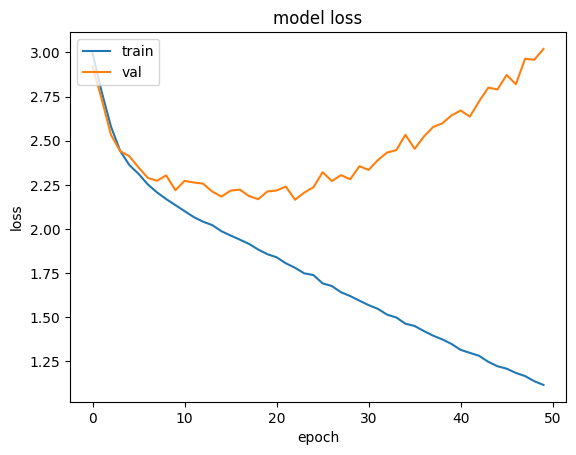

In [10]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

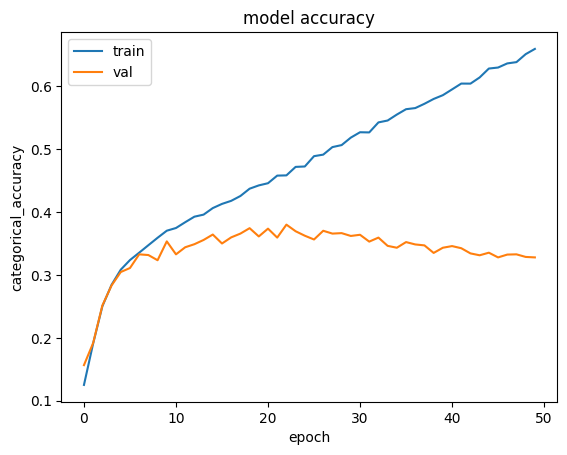

In [11]:
plt.plot(history.history['categorical_accuracy'])
plt.plot(history.history['val_categorical_accuracy'])
plt.title('model accuracy')
plt.ylabel('categorical_accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

As we can see from these plots, our model is overfitting a lot, and the best accuracy is very low, at < 0.4.

Before trying a bigger model, let's just experiment with using keras built-in augmentation techniques.

In [14]:
model = keras.Sequential()
model.add(keras.Input(shape=image_size + (3,), batch_size=batch_size))

model.add(layers.RandAugment())
model.add(layers.Rescaling(1./255)) # standardize RGB values to 0-1 range

model.add(layers.Conv2D(32, 5, strides=2, activation="relu"))
model.add(layers.Conv2D(32, 3, activation="relu"))
model.add(layers.MaxPooling2D(3))

model.add(layers.Conv2D(32, 5, activation="relu"))
model.add(layers.Conv2D(32, 3, activation="relu"))
model.add(layers.MaxPooling2D(3))

model.add(layers.GlobalMaxPooling2D())

model.add(layers.Dense(23, activation="softmax"))

In [15]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rand_augment_1 (RandAugment)    │ (16, 128, 128, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (16, 128, 128, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (16, 62, 62, 32)       │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (16, 60, 60, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (16, 20, 20, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (16, 16, 16, 32)       │        25,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (16, 14, 14, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (16, 4, 4, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d_2          │ (16, 32)               │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (16, 23)               │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,319 (184.84 KB)

 Trainable params: 47,319 (184.84 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(
    optimizer=keras.optimizers.Adam(),
    loss=keras.losses.CategoricalCrossentropy(),
    metrics=[
        keras.metrics.CategoricalAccuracy(),
        keras.metrics.F1Score(),
        keras.metrics.AUC()
    ]
)

In [17]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50
)

Epoch 1/50
667/667 ━━━━━━━━━━━━━━━━━━━━ 54s 66ms/step - auc_1: 0.6087 - categorical_accuracy: 0.0975 - f1_score: 0.0158 - loss: 3.0595 - val_auc_1: 0.6191 - val_categorical_accuracy: 0.1068 - val_f1_score: 0.0144 - val_loss: 3.0396
Epoch 2/50
667/667 ━━━━━━━━━━━━━━━━━━━━ 46s 69ms/step - auc_1: 0.6466 - categorical_accuracy: 0.1178 - f1_score: 0.0282 - loss: 2.9963 - val_auc_1: 0.6821 - val_categorical_accuracy: 0.1612 - val_f1_score: 0.0512 - val_loss: 2.9269
Epoch 3/50
667/667 ━━━━━━━━━━━━━━━━━━━━ 46s 69ms/step - auc_1: 0.6901 - categorical_accuracy: 0.1495 - f1_score: 0.0540 - loss: 2.8993 - val_auc_1: 0.7134 - val_categorical_accuracy: 0.1563 - val_f1_score: 0.0425 - val_loss: 2.8476
Epoch 4/50
667/667 ━━━━━━━━━━━━━━━━━━━━ 120s 181ms/step - auc_1: 0.7093 - categorical_accuracy: 0.1566 - f1_score: 0.0677 - loss: 2.8513 - val_auc_1: 0.7347 - val_categorical_accuracy: 0.1795 - val_f1_score: 0.0568 - val_loss: 2.7705
Epoch 5/50
667/667 ━━━━━━━━━━━━━━━━━━━━ 48s 72ms/step - auc_1: 0.7194 

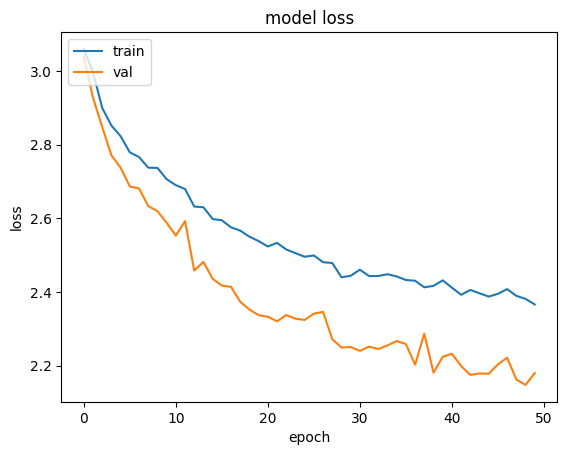

In [18]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

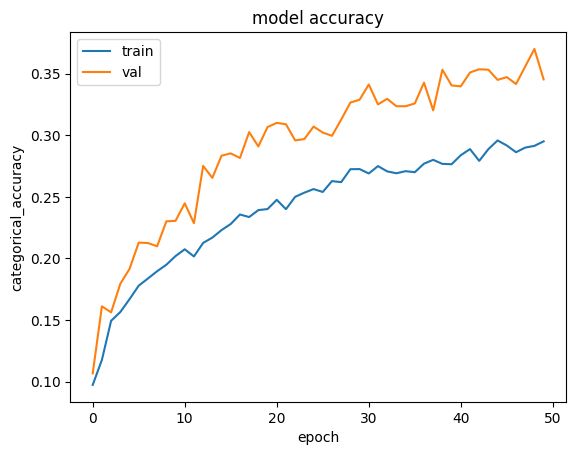

In [19]:
plt.plot(history.history['categorical_accuracy'])
plt.plot(history.history['val_categorical_accuracy'])
plt.title('model accuracy')
plt.ylabel('categorical_accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

Using RandAugment augmentation from keras changed the evolution of our training dramatically,
preventing the model from overfitting, but it took a lot longer to run (5min x 40min, so a ~8x
increase in training time)

In the next notebook we will experiment with some larger custom models